# Podcast Emotion and Content Analysis

This project explores the linguistic, emotional, and topical characteristics of podcast episodes using Natural Language Processing (NLP) methods.  
By combining pre-trained language models and structured metadata, we aim to uncover the emotional tone, thematic categories, and audience alignment of each podcast episode.

Our pipeline operates at two complementary levels:
- **Turn-level analysis:** Emotion detection and safety tagging for individual speaker turns.
- **Episode-level analysis:** Aggregation of features to classify episodes into genres, estimate audience interests, and identify potentially unsafe content.


### Motivation

Podcasts are a rich and fast-growing medium, with content ranging from personal storytelling to political commentary.  
However, the scale and diversity of podcast data make manual analysis impractical.  

Automatic understanding of podcast episodes can support:
- **Listeners**, by improving recommendation and discovery systems.
- **Producers**, by providing insights into emotional tone and audience engagement.
- **Platforms**, by enabling automated content moderation and brand safety filtering.

Despite advances in text-based NLP, podcasts present unique challenges: conversational structure, speaker variability, and diverse topics.  
This project seeks to address these challenges by building an interpretable and scalable NLP pipeline tailored for podcast data.


### Project Goals

The primary objectives of this project are:

1. **Turn-level emotion detection** — Identify emotions (e.g., joy, anger, sadness) in each speaker turn using a pre-trained emotion recognition model.
2. **Episode-level categorization** — Classify each episode into broad categories such as *Technology*, *Comedy*, or *Politics*.
3. **Brand safety detection** — Flag episodes that contain unsafe or sensitive content, including hate speech, violence, or adult themes.
4. **Audience alignment prediction** — Estimate the likely audience or interest group best aligned with each episode based on its emotional and linguistic profile.

Collectively, these tasks aim to produce an interpretable summary of each episode — showing how speakers’ emotions, topics, and tone interact across the conversation.


### Expected Outcomes

By the end of this project, we aim to:
- Deliver a fully documented pipeline capable of processing large-scale podcast transcript data.
- Demonstrate emotion and safety predictions on speaker turns using transformer-based models.
- Aggregate turn-level features to classify and describe entire episodes.
- Provide interpretable summaries for each episode showing emotion distribution, category prediction, and safety assessment.

This proof of concept validates that pre-trained NLP models can be combined and scaled to perform fine-grained, multi-level podcast analysis.


## 1. Data Loading and Overview

To start, we'll load the sample datasets, `episodeLevelDataSample` and `speakerTurnDataSample`. The full datasets are over 20 GB, so we're using these smaller versions for the demonstration in this milestone.

In [1]:
import gzip
import json
import pandas as pd

episode_level = []
with gzip.open("data/episodeLevelDataSample.jsonl.gz", "rt", encoding="utf-8") as f:
    for line in f:
        episode_level.append(json.loads(line))

episode_df = pd.DataFrame(episode_level)

In [2]:
speakerTurn = []
with gzip.open("data/speakerTurnDataSample.jsonl.gz", "rt", encoding="utf-8") as f:
    for line in f:
        speakerTurn.append(json.loads(line))

speaker_df = pd.DataFrame(speakerTurn)

### Columns and Examples

#### Episode Level

The `episodeLevelDataSample` dataset provides metadata for each podcast episode in the sample, including information like the episode title, description, podcast title, and categories. The mp3url in this dataset is particularly important as it acts as a unique identifier for each episode, allowing us to link it with the corresponding speaker turn data later on. We'll use this data to understand the context of the speaker turns and potentially for tasks like episode classification and analysis based on episode-level features.

In [3]:
print("episodeLevelDataSample columns: ", episode_df.keys())

print("\n episodeLevelDataSample examples: ")
episode_df.sample(5) # Display 5 random samples from the dataset

episodeLevelDataSample columns:  Index(['transcript', 'rssUrl', 'epTitle', 'epDescription', 'mp3url',
       'podTitle', 'lastUpdate', 'itunesAuthor', 'itunesOwnerName', 'explicit',
       'imageUrl', 'language', 'createdOn', 'host', 'podDescription',
       'category1', 'category2', 'category3', 'category4', 'category5',
       'category6', 'category7', 'category8', 'category9', 'category10',
       'oldestEpisodeDate', 'episodeDateLocalized', 'durationSeconds',
       'hostPredictedNames', 'numUniqueHosts', 'guestPredictedNames',
       'numUniqueGuests', 'neitherPredictedNames', 'numUniqueNeithers',
       'mainEpSpeakers', 'numMainSpeakers', 'hostSpeakerLabels',
       'guestSpeakerLabels', 'overlapPropTurnCount', 'avgTurnDuration',
       'overlapPropDuration', 'totalSpLabels'],
      dtype='object')

 episodeLevelDataSample examples: 


,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,neitherPredictedNames,numUniqueNeithers,mainEpSpeakers,numMainSpeakers,hostSpeakerLabels,guestSpeakerLabels,overlapPropTurnCount,avgTurnDuration,overlapPropDuration,totalSpLabels
1415,the your microphone picks up like I don't kno...,https://anchor.fm/s/4ad056d4/podcast/rss,Scooters Segment Show,The show where the segments are funny and the ...,https://anchor.fm/s/4ad056d4/podcast/play/2610...,Beer With the Boys,1697715119,beerwiththeboys,beerwiththeboys,1,...,NO_NEITHER_IDENTIFIED,0.0,"[SPEAKER_00, SPEAKER_03]",2.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,0.408434,3.743133,0.086175,4.0
3122,It's 6 p.m. at the campus coffee shop. Your u...,https://feeds.redcircle.com/591ba20a-bdf9-4391...,Ennis Whatley tells stories of Bulls cocaine c...,Ennis Whatley started alongside Michael Jordan...,https://audio3.redcircle.com/episodes/50f40b2e...,Da Windy City: A Chicago Bears Podcast,1697807419,FanSided,FanSided,0,...,"[Larry Bird, Michael Jordan's]",2.0,"[SPEAKER_04, SPEAKER_07, SPEAKER_08]",3.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,0.398113,8.329245,0.027786,10.0
1999,"on the conduit page. So anyway, as guys are c...",https://anchor.fm/s/1f999408/podcast/rss,PSP Don Kennedy 4/2,<p>Don Kennedy from <em>ProMaster Home Repair ...,https://anchor.fm/s/1f999408/podcast/play/1328...,PSP,1629765074,Jerry Beerman,Jerry Beerman,0,...,[Kelly Clark],1.0,"[SPEAKER_00, SPEAKER_01]",2.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,0.492537,11.179104,0.025901,2.0
7051,[MUSIC PLAYING] And how are you all doing? Th...,https://anchor.fm/s/1a51d208/podcast/rss,Personal Growth When going gets tough - Author...,Personal Growth When going gets tough - Author...,https://anchor.fm/s/1a51d208/podcast/play/1479...,Author Sherry International Public Speaking Coach,1633839482,Author Sherry,Author Sherry,0,...,[Vishalik Oshik],1.0,[SPEAKER_00],1.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,0.0,252.08,0.0,1.0
630,"[Music] Hey there guys and gals, eks and game...",https://feeds.captivate.fm/nogcast/,REST,<p>This episode the crew talks about the end o...,https://podcasts.captivate.fm/media/70ce1524-5...,Nerd of Godcast,1697577266,Nerd of Godcast,Nerd of Godcast,0,...,"[Lee Smoddy, Steve O'Sepremo, Ico cacola]",3.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE


#### Speaker Turn Level

The `speakerTurnDataSample` dataset contains information about individual speaker turns within each podcast episode. This includes the most important one which is the actual text spoken (`turnText`), the identified speaker, the start and end times of the turn, and the mp3url to link it back to the episode metadata in the episodeLevelDataSample.

In [4]:
print("speakerTurnDataSample columns: ", speaker_df.keys())

print("\n speakerTurnDataSample examples: ")
speaker_df.sample(5) # Display 5 random samples from the dataset

speakerTurnDataSample columns:  Index(['mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean', 'mfcc4_sma3Mean',
       'F0semitoneFrom27.5Hz_sma3nzMean', 'F1frequency_sma3nzMean', 'turnText',
       'speaker', 'startTime', 'endTime', 'duration', 'mp3url', 'turnCount',
       'inferredSpeakerRole', 'inferredSpeakerName'],
      dtype='object')

 speakerTurnDataSample examples: 


,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27.5Hz_sma3nzMean,F1frequency_sma3nzMean,turnText,speaker,startTime,endTime,duration,mp3url,turnCount,inferredSpeakerRole,inferredSpeakerName
174748,21.311147,16.236958,18.401894,15.604383,27.395991,631.858950,. - Was this an,[SPEAKER_01],274.40,275.02,0.62,https://anchor.fm/s/3e1c571c/podcast/play/2193...,74,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
170350,30.053588,-6.572470,15.005216,7.625788,13.015614,704.499155,. - Right. So I'm curious how you arrived at y...,[SPEAKER_02],257.69,272.47,14.78,https://www.podtrac.com/pts/redirect.mp3/pdst....,20,host,Jay Hasbrooke
150019,31.303279,1.291919,27.041065,20.821147,25.869112,609.714417,.,[SPEAKER_00],150.79,151.00,0.21,https://anchor.fm/s/74a72f0/podcast/play/15568...,46,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
81875,41.482642,-17.290126,-18.021339,5.326347,29.192840,760.027625,.,"[SPEAKER_03, SPEAKER_01]",2600.57,2601.02,0.45,https://dancing-into-parenthood-podcast.s3.us-...,303,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
90211,22.034143,-0.412005,11.594639,6.557130,16.132057,614.142193,"- Yeah, 'cause people are like, oh my God, I ...",[SPEAKER_00],2590.76,2596.00,5.24,https://api.spreaker.com/download/episode/3187...,574,host,Will Diesley


Given the large number of columns in these datasets, we want to select a subset of columns from each that are relevant to our analysis and discard the rest.

## 2. Data Preprocessing

In this section, we perform a series of preprocessing steps to prepare the dataset for downstream analysis and modeling.

The primary objective is to retain only the most relevant information from the raw `speakerTurnData` and `episodeLevelData` sources while ensuring that textual fields — particularly `turnText` — are clean, standardized, and ready for the tasks.

This involves:

* Selecting key columns that capture speaker and episode metadata.
* Cleaning and normalizing text data to remove noise (e.g., music markers, punctuation, excess whitespace).
* Filtering out irrelevant or empty content.
* Aggregating speaker turns and merging with episode-level information for a unified dataset.

### 2.1 Select Relevant Columns (Speaker-Turn Data)
We extract a subset of columns from the original dataset to create a compact version containing the most informative features for each speaker turn.

| Column                  | Description                                                |
| :---------------------- | :--------------------------------------------------------- |
| **turnText**            | Transcribed text of the speaker’s turn                     |
| **speaker**             | Identifier for the speaker                                 |
| **mp3url**              | Link to the episode (useful for grouping turns by episode) |
| **turnCount**           | Sequential position of the turn within an episode          |
| **inferredSpeakerRole** | Predicted speaker role (e.g., host, guest)                 |
| **startTime**           | Start time of a turn                                       |
| **endTime**             | End time of a turn                                         |


In [5]:
cols = ['turnText', 'speaker', 'mp3url', 'turnCount', 'inferredSpeakerRole',  'startTime', 'endTime']
speaker_df1 = pd.DataFrame(speakerTurn)[cols].copy()

speaker_df1[:20]

,turnText,speaker,mp3url,turnCount,inferredSpeakerRole,startTime,endTime
0,I'm Simon Shapiro and this is Sing Out Speak ...,[SPEAKER_00],https://www.buzzsprout.com/783020/4252475-best...,1,host,0.00,60.00
1,I'm Simon Shapiro and this is Sing Out Speak ...,[SPEAKER_00],https://www.buzzsprout.com/783020/4165286-it-s...,1,host,0.00,78.16
2,Music] [Music] [Music] [Music] [Music] [,[SPEAKER_02],https://www.buzzsprout.com/783020/4165286-it-s...,2,NO_INFERRED_ROLE,78.16,115.31
3,Music] [Music] [Music] [Music] [Music] [Music]...,[SPEAKER_01],https://www.buzzsprout.com/783020/4165286-it-s...,3,NO_INFERRED_ROLE,115.31,360.16
4,I'm Simon Shapiro and this is Sing Out Speak ...,[SPEAKER_05],https://www.buzzsprout.com/783020/3983942-toda...,1,host,0.00,36.99
5,.,"[SPEAKER_05, SPEAKER_00]",https://www.buzzsprout.com/783020/3983942-toda...,2,NO_INFERRED_ROLE,36.99,37.44
6,Well hello everyone and welcome,[SPEAKER_00],https://www.buzzsprout.com/783020/3983942-toda...,3,NO_INFERRED_ROLE,37.44,42.42
7,to Sing Out Speak Out episode number 20. I kn...,[SPEAKER_05],https://www.buzzsprout.com/783020/3983942-toda...,4,host,42.42,162.76
8,Music] [Music] [Music] [Music] [Music] [,[SPEAKER_01],https://www.buzzsprout.com/783020/3983942-toda...,5,NO_INFERRED_ROLE,162.76,172.76
9,Music] [Music] [Music] [Music] [Music] [Music]...,[SPEAKER_02],https://www.buzzsprout.com/783020/3983942-toda...,6,NO_INFERRED_ROLE,172.76,203.64


In [6]:
print(f"Total number of turns: {len(speaker_df1)}")
average_text_length = speaker_df1['turnText'].str.len().mean()
print(f"Average turn text length: {average_text_length:.2f}")
average_word_length = speaker_df1['turnText'].apply(lambda x: len(str(x).split())).mean()
print(f"Average number of words: {average_word_length:.2f}")

Total number of turns: 200000
Average turn text length: 160.21
Average number of words: 30.63


#### 2.1.1 Distribution of Turn Text Lengths

This histogram shows the distribution of the length of each speaker turn in characters. A logarithmic scale is used on the x-axis to accommodate the wide range of turn lengths, including some very long turns. Understanding turn length distribution is important for selecting appropriate NLP models and processing strategies.

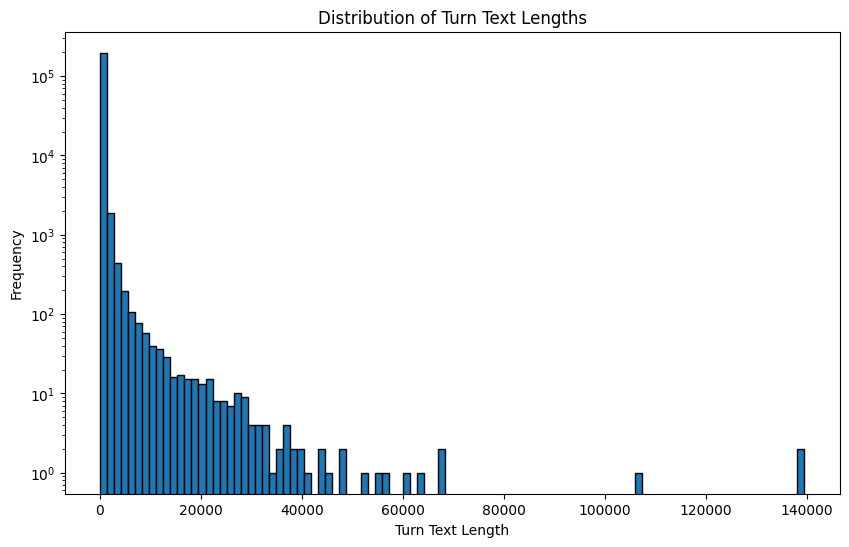

In [7]:
import matplotlib.pyplot as plt

# Plot a histogram of the turn text lengths
turn_lengths = speaker_df1['turnText'].str.len().tolist()
plt.figure(figsize=(10, 6))
plt.hist(turn_lengths, bins=100, edgecolor='black')
plt.xlabel('Turn Text Length')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Distribution of Turn Text Lengths')
plt.show()

#### 2.1.2 Top 20 of most common length turns

In [8]:
from collections import Counter

length_counts = Counter(turn_lengths)

for length, count in length_counts.most_common(20):
    print(f"Length {length}: {count} turns")

Length 5: 14765 turns
Length 1: 9616 turns
Length 6: 9008 turns
Length 4: 8923 turns
Length 3: 7101 turns
Length 7: 6090 turns
Length 8: 5947 turns
Length 9: 5187 turns
Length 10: 4788 turns
Length 11: 4358 turns
Length 2: 3993 turns
Length 12: 3752 turns
Length 13: 3498 turns
Length 14: 3253 turns
Length 15: 2888 turns
Length 16: 2783 turns
Length 17: 2375 turns
Length 18: 2256 turns
Length 19: 2102 turns
Length 20: 1870 turns


### 2.2 Text Normalization

We standardize the text to lowercase and normalize whitespace.
This step ensures consistent tokenization and reduces vocabulary redundancy (e.g., “The” and “the” are treated the same).

In [9]:
print(speaker_df1['turnText'][0])

speaker_df1['filtered_text'] = (
    speaker_df1['turnText']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print(speaker_df1['filtered_text'][0])

 I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. So here are my five F's of being five. Fantasy. Kids are amazing at jumping into fantasy, not just make believe but believe believe. We're in the car waiting for someone to come and help us because it's broken down. I suggest let's pretend we're space man.
i'm simon shapiro and this is sing out speak out. here i give you the philosophies, ideas and songs i've been working on for many years but until now i've shared just too few of because i've been afraid of you and worse i've been afraid of me. my will to connect with you and share the best of me has grown greater than any fear and that's why i am compelled t

### 2.3 Noise Removal

The transcripts contain several types of non-linguistic artifacts such as musical cues, blank-audio markers, ellipses, and transcription symbols.

These tokens provide no semantic value and can bias subsequent NLP analysis.

To obtain cleaner text representations, we remove all non-speech elements and normalize leftover formatting.

In [10]:
import re

# --- 1. Define stronger unwanted patterns ---
# Matches variations like:
# [music], (music playing), [background music fades], music:, blank_audio etc.
unwanted_patterns = [
    r'\[.*?music.*?\]',       # [music], [background music], [music playing]
    r'\(.*?music.*?\)',       # (music), (music playing), (background music)
    r'\[.*?blank_audio.*?\]', # [blank_audio] or variations
    r'\(.*?blank_audio.*?\)', # (blank_audio)
    r'\bmusic\b',             # standalone 'music'
    r'\bblank_audio\b'        # standalone 'blank_audio'
]

# --- 2. Apply removal ---
for pattern in unwanted_patterns:
    speaker_df1['filtered_text'] = speaker_df1['filtered_text'].str.replace(pattern, '', regex=True)

# --- 3. Clean malformed or stray brackets ---
def clean_brackets(text):
    """Removes stray [ or ] while preserving valid bracketed expressions."""
    return re.sub(r'(\[[^\[\]]+\])|[\[\]]', lambda m: m.group(1) or '', text)

speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(clean_brackets)

# --- 4. Remove conversation markers or ellipses ---
speaker_df1['filtered_text'] = (
    speaker_df1['filtered_text']
    .str.replace('>>', '', regex=False)
    .str.replace(r'\.\.\.', '', regex=True)  # remove ...
)

# --- 4. Remove near-empty or symbol-only entries ---
speaker_df1 = speaker_df1[speaker_df1['filtered_text'].str.len() > 1]
speaker_df1 = speaker_df1[~speaker_df1['filtered_text'].str.match(r'^\W*$')]

# --- 6. Final whitespace normalization ---
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

speaker_df1[['turnText','filtered_text']][:20]


,turnText,filtered_text
0,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...
1,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...
4,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...
6,Well hello everyone and welcome,well hello everyone and welcome
7,to Sing Out Speak Out episode number 20. I kn...,to sing out speak out episode number 20. i kno...
12,Music] [Music] You'll expend the restore Jump ...,you'll expend the restore jump slower on the same
13,reflection If you're never gonna change direc...,reflection if you're never gonna change direct...
14,Today is yesterday Press room on and press th...,today is yesterday press room on and press the...
15,"If you like the song, it's available at all t...","if you like the song, it's available at all th..."
17,I'm Simon Shapiro and this is Sing Out Speak ...,i'm simon shapiro and this is sing out speak o...


### 2.4 Token-Level and Structural Cleaning

At this stage, we refine the cleaned transcripts to make them suitable for modeling.
This involves removing punctuation and stopwords, merging consecutive turns from the same speaker, and filtering out low-information text segments.

#### 2.4.1 Text Standardization and Punctuation Removal

We define a text-cleaning function that lowercases the text, trims whitespace, and optionally removes punctuation.
This ensures consistency in tokenization and reduces vocabulary fragmentation

In [11]:
import string

def clean_text(text, remove_punct=True):
    """
    Lowercase, trim, and optionally remove punctuation.
    Handles missing or non-string entries safely.
    """
    if isinstance(text, str):
        if remove_punct:
            text = text.translate(str.maketrans('', '', string.punctuation))
        return text.lower().strip()
    return text

# Apply the cleaning function
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(clean_text)

speaker_df1[['turnText','filtered_text']][:20]


,turnText,filtered_text
0,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...
1,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...
4,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...
6,Well hello everyone and welcome,well hello everyone and welcome
7,to Sing Out Speak Out episode number 20. I kn...,to sing out speak out episode number 20 i know...
12,Music] [Music] You'll expend the restore Jump ...,youll expend the restore jump slower on the same
13,reflection If you're never gonna change direc...,reflection if youre never gonna change directi...
14,Today is yesterday Press room on and press th...,today is yesterday press room on and press the...
15,"If you like the song, it's available at all t...",if you like the song its available at all the ...
17,I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro and this is sing out speak ou...


#### 2.4.2 Merge Consecutive Turns by the Same Speaker

Some transcripts split a speaker’s speech into multiple turns even when uninterrupted.
To maintain coherent speaker contributions, we merge consecutive turns by the same speaker into single entries.

In [12]:
print(f'Number of turns before merging: {len(speaker_df1)}')

# Ensure the speaker field is a string
speaker_df1['speaker'] = speaker_df1['speaker'].apply(
    lambda x: ','.join(x) if isinstance(x, list) else str(x)
)

# Create a group index that increments when the speaker changes
speaker_df1['group'] = (speaker_df1['speaker'] != speaker_df1['speaker'].shift()).cumsum()

# Merge consecutive text segments by the same speaker
merged_df = (
    speaker_df1
    .groupby(['group', 'speaker'], as_index=False)
    .agg({
        'turnText': lambda x: ' '.join(x),
        'filtered_text': lambda x: ' '.join(x),      # concatenate text
        'startTime': 'first',                   # earliest start time
        'endTime': 'last',                      # latest end time
        'mp3url': 'first',                      # keep the episode link
        'inferredSpeakerRole': 'first',         # role stays the same for the speaker
    })
)

# Turn it back as a list
# Turn it back as a list
merged_df['speaker'] = merged_df['speaker'].apply(
    lambda x: [s.strip() for s in x.split(',')] if isinstance(x, str) else x
)

# Drop the temporary grouping column if not needed
speaker_df1 = merged_df.drop(columns=['group'], errors='ignore')

print(f'Number of turns after merging: {len(speaker_df1)}')

speaker_df1[['speaker','filtered_text']][:20]


Number of turns before merging: 186736
Number of turns after merging: 184081


,speaker,filtered_text
0,[SPEAKER_00],im simon shapiro and this is sing out speak ou...
1,[SPEAKER_05],im simon shapiro and this is sing out speak ou...
2,[SPEAKER_00],well hello everyone and welcome
3,[SPEAKER_05],to sing out speak out episode number 20 i know...
4,[SPEAKER_03],youll expend the restore jump slower on the same
5,[SPEAKER_04],reflection if youre never gonna change directi...
6,[SPEAKER_03],today is yesterday press room on and press the...
7,[SPEAKER_05],if you like the song its available at all the ...
8,[SPEAKER_03],im simon shapiro and this is sing out speak ou...
9,"[SPEAKER_03, SPEAKER_02]",hi i


#### 2.4.3 Stopword Removal

Stopwords (e.g., the, is, and) are common words that typically carry little semantic meaning.

Removing them reduces noise and emphasizes content-bearing terms.

In [13]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Remove stopwords from each turn
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

speaker_df1[:20]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cristinasemikina/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,speaker,turnText,filtered_text,startTime,endTime,mp3url,inferredSpeakerRole
0,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host
1,[SPEAKER_05],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host
2,[SPEAKER_00],Well hello everyone and welcome,well hello everyone welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
3,[SPEAKER_05],to Sing Out Speak Out episode number 20. I kn...,sing speak episode number 20 know crazy going ...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host
4,[SPEAKER_03],Music] [Music] You'll expend the restore Jump ...,youll expend restore jump slower,230.76,240.64,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
5,[SPEAKER_04],reflection If you're never gonna change direc...,reflection youre never gonna change direction ...,240.64,267.48,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
6,[SPEAKER_03],Today is yesterday Press room on and press th...,today yesterday press room press line today ye...,289.28,376.28,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
7,[SPEAKER_05],"If you like the song, it's available at all t...",like song available places usually download st...,376.28,408.28,https://www.buzzsprout.com/783020/3983942-toda...,host
8,[SPEAKER_03],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,37.20,https://www.buzzsprout.com/783020/3892169-satu...,host
9,"[SPEAKER_03, SPEAKER_02]",Hi I,hi,37.20,37.84,https://www.buzzsprout.com/783020/3892169-satu...,NO_INFERRED_ROLE


#### 2.4.4 Remove Extremely Short or Low-Information Turns

Short turns (single words such as “yeah”, “okay”, or “right”) often add noise to topic or embedding models.
We remove these to focus the analysis on meaningful utterances.

In [14]:
# Keep only turns with more than one word
old_len = len(speaker_df1)
speaker_df1 = speaker_df1[speaker_df1['filtered_text'].apply(lambda x: len(str(x).split()) > 1)]

print(f'Number of turns before cleanup: {old_len}')
print(f"Total number of turns: {len(speaker_df1)}")
average_text_length = speaker_df1['filtered_text'].str.len().mean()
print(f"Average turn text length: {average_text_length:.2f}")
average_word_length = speaker_df1['filtered_text'].apply(lambda x: len(str(x).split())).mean()
print(f"Average number of words: {average_word_length:.2f}")

Number of turns before cleanup: 184081
Total number of turns: 106124
Average turn text length: 171.21
Average number of words: 26.66


#### 2.4.5 Split Extremely Long Turns

Some episodes contain single, very long continuing speaker turns. If we leave these intact, a whole episode may receive one emotion label even though the speaker's tone and sentiment evolve. Below we split turns that exceed a configurable length into smaller contiguous chunks (prefer sentence boundaries where possible, otherwise by character limits). This preserves episode/speaker metadata and creates `speaker_df1_expanded` so downstream emotion analysis can show emotion progression across a single episode.


In [15]:
print("DataFrame after splitting long turn texts:")
print("\nOriginal speaker_df1 shape:", speaker_df1.shape)

# Split long texts into chunks and explode into new rows
def split_long_text(text, max_length=500):
    if isinstance(text, str):
        return [text[i:i+max_length] for i in range(0, len(text), max_length)]
    return [text]

# Apply the splitting function to filtered_text
speaker_df1['filtered_text'] = speaker_df1['filtered_text'].apply(split_long_text)

# Explode the list of split texts into new rows, keeping all other columns
speaker_df1 = speaker_df1.explode('filtered_text').reset_index(drop=True)

print("speaker_df1 after splitting and exploding long turn texts:")
display(speaker_df1.head())
print("speaker_df1 shape after splitting:", speaker_df1.shape)

DataFrame after splitting long turn texts:

Original speaker_df1 shape: (106124, 7)
speaker_df1 after splitting and exploding long turn texts:


,speaker,turnText,filtered_text,startTime,endTime,mp3url,inferredSpeakerRole
0,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host
1,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,ompelled sing speak well everyone crazy busy w...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host
2,[SPEAKER_05],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host
3,[SPEAKER_00],Well hello everyone and welcome,well hello everyone welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE
4,[SPEAKER_05],to Sing Out Speak Out episode number 20. I kn...,sing speak episode number 20 know crazy going ...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host


speaker_df1 shape after splitting: (123379, 7)


##### 2.4.5.1 Distribution of Turn Text Lengths after cleanup

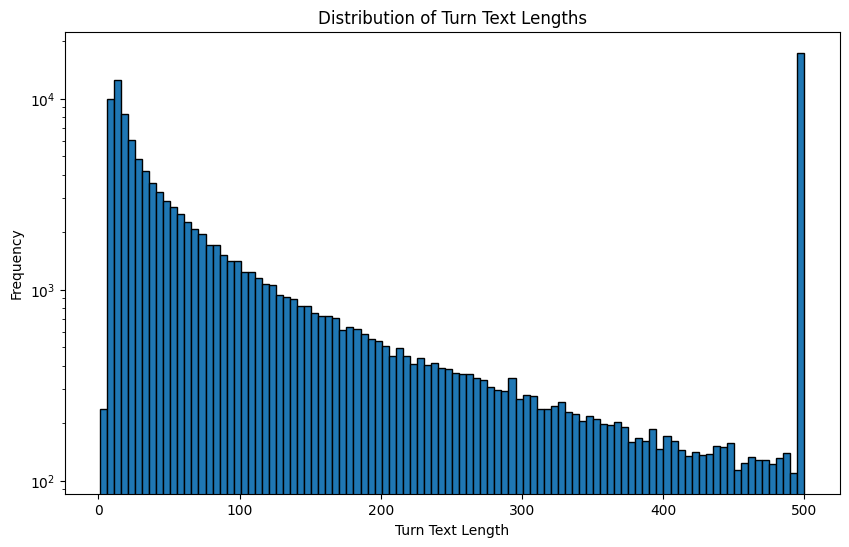

In [16]:
# Plot a histogram of the turn text lengths
turn_lengths = speaker_df1['filtered_text'].str.len().tolist()
plt.figure(figsize=(10, 6))
plt.hist(turn_lengths, bins=100, edgecolor='black')
plt.xlabel('Turn Text Length')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Distribution of Turn Text Lengths')
plt.show()

##### 2.4.5.2 Top 20 of most common length turns

In [17]:
from collections import Counter

length_counts = Counter(turn_lengths)

for length, count in length_counts.most_common(20):
    print(f"Length {length}: {count} turns")

Length 500: 17274 turns
Length 9: 3646 turns
Length 10: 3151 turns
Length 11: 2964 turns
Length 12: 2424 turns
Length 13: 2369 turns
Length 14: 2367 turns
Length 15: 2347 turns
Length 16: 1976 turns
Length 8: 1752 turns
Length 17: 1730 turns
Length 19: 1570 turns
Length 18: 1517 turns
Length 20: 1505 turns
Length 21: 1371 turns
Length 22: 1242 turns
Length 23: 1218 turns
Length 25: 1106 turns
Length 24: 1099 turns
Length 7: 1099 turns


#### 2.4.6 Final Output

In [18]:
for index, row in speaker_df1.iloc[420:425].iterrows():
    print(f"Speaker  : {row['speaker']}")
    print(f"Original : {row['turnText'][:100]}... ({len(row['turnText'])} length)",)
    print(f"Filtered : {row['filtered_text'][:100]}... ({len(row['filtered_text'])} length)",)
    print()

Speaker  : ['SPEAKER_02']
Original : . It's all good. It's all good. All right. We also got a message from our resident general authority... (1069 length)
Filtered : good good right also got message resident general authority shannon grover love much shannon shannon... (500 length)

Speaker  : ['SPEAKER_02']
Original : . It's all good. It's all good. All right. We also got a message from our resident general authority... (1069 length)
Filtered : ats good pastor would hey anything help enough food need go grocery store pick anything like sounds ... (130 length)

Speaker  : ['SPEAKER_02']
Original :  called to talk to us about tithing and why we weren't paying tithing. Of course. I told him I belie... (485 length)
Filtered : called talk us tithing werent paying tithing course told believe lord would rather us provide famili... (273 length)

Speaker  : ['SPEAKER_02']
Original :  awesome. Then at the end, it says, "He went on to say that maybe we could put some of our expenses ... (1353 le

### 2.5 Episode-Level Preprocessing

#### 2.5.1 Select Relevant Columns
We extract a subset of columns from the original `episodeLevelData` DataFrame, focusing on those that provide contextual and categorical information about each episode.

| Column                           | Description                                                   |
| :------------------------------- | :------------------------------------------------------------ |
| **epTitle**, **epDescription**   | Episode title and description                                 |
| **mp3url**                       | Unique episode identifier (used to link with speaker turns)   |
| **podTitle**, **podDescription** | Podcast-level metadata for context and categorization         |
| **explicit**                     | Flag indicating whether the episode contains explicit content |
| **category1–category10**         | Topical categories associated with the episode                |



In [19]:
episode_df1 = episode_df[[
    'epTitle', 'mp3url', 'podTitle', 'explicit',
    'category1', 'category2', 'category3', 'category4', 'category5',
    'category6', 'category7', 'category8', 'category9', 'category10'
]].copy()

episode_df1[:20]


,epTitle,mp3url,podTitle,explicit,category1,category2,category3,category4,category5,category6,category7,category8,category9,category10
0,Best of SingOut SpeakOut No.3,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
1,It's All Gone,https://www.buzzsprout.com/783020/4165286-it-s...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
2,Today Is Yesterday,https://www.buzzsprout.com/783020/3983942-toda...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
3,Saturn Return,https://www.buzzsprout.com/783020/3892169-satu...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
4,Quarterlife Crisis,https://www.buzzsprout.com/783020/3791501-quar...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
5,BE: Episode 38 - Why Black Educators Feel Emot...,https://mcdn.podbean.com/mf/web/as0pgw/Why_Bla...,Brazen Education,0,education,self improvement,how to,None,None,None,None,None,None,None
6,BE: Episode 37 - The Benefits of Homeschooling...,https://mcdn.podbean.com/mf/web/0zwxdc/The_Ben...,Brazen Education,0,education,self improvement,how to,None,None,None,None,None,None,None
7,Episode 33 'California’s Higher Education Lan...,http://dts.podtrac.com/redirect.mp3/feeds.soun...,California Community Colleges Podcast,0,education,None,None,None,None,None,None,None,None,None
8,2.20: The NHL Will Continue Until Morale Improves,https://chrt.fm/track/D4A77F/traffic.megaphone...,Puck Bunnies,1,sports,hockey,None,None,None,None,None,None,None,None
9,What causes anxiety?,https://mcdn.podbean.com/mf/web/1o71dp/What_ca...,Anxiety 2 Confidence podcast,0,health,fitness,mental,education,self improvement,None,None,None,None,None


In [20]:
# How many unique episodes?
unique_episodes_count = len(episode_df1['mp3url'].unique())
print(f"Number of unique episodes: {unique_episodes_count}")


# How many different categories in total?
category_columns = [f'category{i}' for i in range(1, 9)]
all_categories = episode_df1[category_columns].values.flatten()
unique_categories = pd.Series(all_categories).dropna().unique()
total_unique_categories = len(unique_categories)
print(f"\nTotal number of unique categories: {total_unique_categories}")


Number of unique episodes: 10000

Total number of unique categories: 99


#### 2.5.2 Handle Missing and Sparse Fields

We first check for missing values in key columns.

Given the dataset’s large size, a small number of missing entries can be safely dropped without compromising representativeness

In [21]:
print("\nMissing values in episode_df1:")
print(episode_df1[['epTitle', 'mp3url', 'podTitle', 'category1']].isnull().sum())

category_columns = [f'category{i}' for i in range(1, 11)]
unique_episodes_count = len(episode_df1['mp3url'].unique())

print("\nNumber of episodes with each category:")
for col in category_columns:
    count = episode_df1[col].notnull().sum()
    print(f"{col}: {count}/{unique_episodes_count}")



Missing values in episode_df1:
epTitle      0
mp3url       0
podTitle     7
category1    9
dtype: int64

Number of episodes with each category:
category1: 9991/10000
category2: 8082/10000
category3: 4257/10000
category4: 2055/10000
category5: 1152/10000
category6: 565/10000
category7: 273/10000
category8: 13/10000
category9: 0/10000
category10: 0/10000


In [22]:
# What categories are represented and any imbalance?
# We can look at the distribution of the first category as a starting point
print("\nDistribution of Category1:")
print('Number of unique categories: ', len(episode_df1['category1'].value_counts()))
print(episode_df1['category1'].value_counts())

print("\nDistribution of Category2:")
print('Number of unique categories: ', len(episode_df1['category2'].value_counts()))
print(episode_df1['category2'].value_counts())

print("\nDistribution of Category3:")
print('Number of unique categories: ', len(episode_df1['category3'].value_counts()))
print(episode_df1['category3'].value_counts())


Distribution of Category1:
Number of unique categories:  20
category1
religion      1982
business      1153
society       1118
education      977
sports         901
health         779
news           496
comedy         490
arts           411
music          372
tv             364
leisure        338
kids           135
science        131
technology     115
fiction         58
true crime      48
history         42
government      41
games           40
Name: count, dtype: int64

Distribution of Category2:
Number of unique categories:  75
category2
spirituality        1982
culture             1118
fitness              762
self improvement     536
film                 364
                    ... 
technology             2
chemistry              2
crafts                 2
nature                 1
stand-up               1
Name: count, Length: 75, dtype: int64

Distribution of Category3:
Number of unique categories:  74
category3
christianity    1196
personal         266
mental           205
news 

In [23]:
# Check for missing values in key columns
print("\nMissing values in episode_df1:")
print(episode_df1[['epTitle', 'mp3url', 'podTitle', 'category1']].isnull().sum())


Missing values in episode_df1:
epTitle      0
mp3url       0
podTitle     7
category1    9
dtype: int64


Most episodes include only a few categories, with all values in `category9` and `category10` being empty.

We therefore remove these two columns to reduce sparsity and simplify the dataset.

In [24]:
print(f"Shape of episode_df1 before dropping missing values and columns: {episode_df1.shape}")

def drop_missing_values_and_columns_episodelvl(episode_dataframe):
    """
    Drop rows missing key metadata and remove unused category columns.
    """
    # Drop rows missing critical fields
    episode_dataframe1 = episode_dataframe.dropna(subset=['podTitle', 'category1'])

    # Drop category9 and category10 if they exist
    columns_to_drop = ['category9', 'category10']
    existing_columns_to_drop = [c for c in columns_to_drop if c in episode_dataframe1.columns]
    if existing_columns_to_drop:
        episode_dataframe1 = episode_dataframe1.drop(columns=existing_columns_to_drop)
    return episode_dataframe1

# Apply the cleanup
episode_df1 = drop_missing_values_and_columns_episodelvl(episode_df1)

print(f"Shape of episode_df1 after dropping missing values and columns: {episode_df1.shape}")


Shape of episode_df1 before dropping missing values and columns: (10000, 14)
Shape of episode_df1 after dropping missing values and columns: (9984, 12)


### 2.6 Merge TurnText - and Episode-Level Data

At this stage, we combine the cleaned speaker-turn and episode-level data to form a unified dataset at the episode level.

This step allows us to analyze or model episodes holistically — using both metadata and spoken content.

#### 2.6.1 Aggregate Speaker Turns per Episode

We first group all turnText entries by mp3url (the episode identifier) and concatenate them into a single text block for each episode.

In [25]:
# Group speaker turns by episode (mp3url) and concatenate the turnText
episode_text_df = (
    speaker_df1
    .groupby('mp3url')
    .apply(lambda df: [
        {
            "speaker": str(row['speaker']),
            "turnText": str(row['filtered_text']),
            # optional: include timing info if available
            **({"startTime": row['startTime'], "endTime": row['endTime']} 
               if 'startTime' in df.columns and 'endTime' in df.columns else {})
        }
        for _, row in df.iterrows()
    ])
    .reset_index(name='turns_list')
)

episode_text_df[:5]


/var/folders/qv/8ghds0hx12s2tw7v8qcq17580000gn/T/ipykernel_47730/236050573.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: [


,mp3url,turns_list
0,http://downloads.newcastle.edu.au/2nur/audio/f...,"[{'speaker': '['SPEAKER_04']', 'turnText': 'tw..."
1,http://downloads.newcastle.edu.au/2nur/audio/f...,"[{'speaker': '['SPEAKER_01']', 'turnText': 'er..."
2,http://dts.podtrac.com/redirect.mp3/feeds.soun...,"[{'speaker': '['SPEAKER_00']', 'turnText': 'hi..."
3,http://dts.podtrac.com/redirect.mp3/feeds.soun...,"[{'speaker': '['SPEAKER_01']', 'turnText': 'he..."
4,http://dts.podtrac.com/redirect.mp3/feeds.soun...,"[{'speaker': '['SPEAKER_03']', 'turnText': 'go..."


#### 2.6.2 Merge Turns with Episode

We then merge the aggregated text with `episode_df1` using `mp3url` as the join key.

In [26]:
# Merge the combined text with episode-level dataframe
episode_df1 = pd.merge(episode_df1, episode_text_df, on='mp3url', how='left')
print(f'Number of episodes before cleanup: {len(episode_df1)}')

# Keep only episodes that actually exist in speaker_df1
valid_urls = set(speaker_df1['mp3url'])
episode_df1 = episode_df1[episode_df1['mp3url'].isin(valid_urls)].reset_index(drop=True)
print(f'Number of episodes after cleanup: {len(episode_df1)}')

episode_df1[:5]

Number of episodes before cleanup: 9984
Number of episodes after cleanup: 907


,epTitle,mp3url,podTitle,explicit,category1,category2,category3,category4,category5,category6,category7,category8,turns_list
0,Best of SingOut SpeakOut No.3,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_00']', 'turnText': 'im..."
1,Today Is Yesterday,https://www.buzzsprout.com/783020/3983942-toda...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_05']', 'turnText': 'im..."
2,Saturn Return,https://www.buzzsprout.com/783020/3892169-satu...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_03']', 'turnText': 'im..."
3,Quarterlife Crisis,https://www.buzzsprout.com/783020/3791501-quar...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,"[{'speaker': '['SPEAKER_00']', 'turnText': 'im..."
4,Episode 33 'California’s Higher Education Lan...,http://dts.podtrac.com/redirect.mp3/feeds.soun...,California Community Colleges Podcast,0,education,None,None,None,None,None,None,None,"[{'speaker': '['SPEAKER_00']', 'turnText': 'hi..."


This results in one row per episode, containing:

* metadata (e.g., title, categories),
* and the entire spoken transcript as turns_list.

##### 2.6.2.1 Distribution of Turns per Episode
This histogram shows the distribution of the number of speaker turns within each podcast episode. This helps us understand the typical conversational structure and density of the episodes in the dataset.

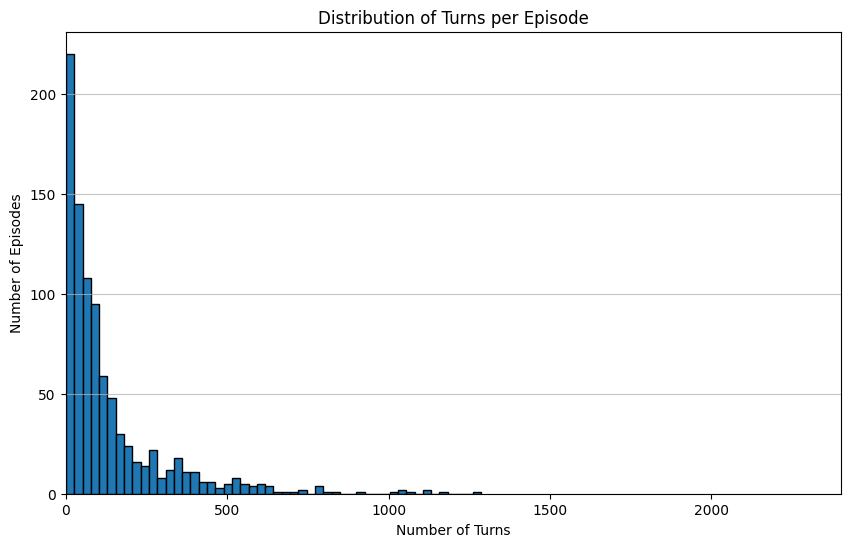

In [27]:
# Calculate the number of turns per episode
turns_per_episode_counts = episode_df1['turns_list'].apply(len).tolist()

# Plot a histogram of the number of turns per episode
plt.figure(figsize=(10, 6))
plt.hist(turns_per_episode_counts, bins=50, edgecolor='black')
plt.title('Distribution of Turns per Episode')
plt.xlabel('Number of Turns')
plt.ylabel('Number of Episodes')
plt.xlim(0, 2400)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [28]:
# How many turns per episode?
turns_per_episode = episode_df1['turns_list'].apply(len).mean()
print(f"Average turns per episode: {turns_per_episode:.2f}")

# How many speakers per episode?
# The 'speaker' column appears to be lists of speaker labels.
def count_unique_speakers_list(speaker_list):
    # Ensure the input is a list before counting unique speakers
    if isinstance(speaker_list, list):
        return len(set(speaker_list))
    else:
        # Print the problematic entry and its type if it's not a list
        print(f"Unexpected type in speaker column: {speaker_list}, Type: {type(speaker_list)}")
        return 0 # Handle cases where the entry is not a list

speaker_df1['num_speakers'] = speaker_df1['speaker'].apply(count_unique_speakers_list)
speakers_per_episode = speaker_df1.groupby('mp3url')['num_speakers'].max().mean()
print(f"Average speakers per episode: {speakers_per_episode:.2f}")

Average turns per episode: 136.03
Average speakers per episode: 1.90


*Note: The y-axis is logarithmic.*

An interesting observation is that the **vast majority** of `turnText` segments are quite short. This suggests that in episodes featuring multiple speakers, frequent interruptions or rapid exchanges may lead to very brief interactions. This pattern is important to keep in mind when feeding the emotion model, as an abundance of short turns could distort the overall emotion distribution at the episode level.

On the other hand, there are also a number of turns **exceeding 10,000 characters**, which are likely outliers caused by transcription or merging artifacts. These unusually long turns can also bias model performance and will require a separate cleaning or truncation strategy in later preprocessing steps. **(TO DO)**


#### 2.6.3 Add Episode Title to Speaker Level Dataset

We can also add the episode titles to speakerLevel dataset, which will come in handy later.

In [29]:
# Merge speaker_df1 with episode_df1 to get the episode title
speaker_df1 = pd.merge(speaker_df1, episode_df1[['mp3url', 'epTitle']], on='mp3url', how='left')

# Display the first few rows to verify the new column
display(speaker_df1.head())

,speaker,turnText,filtered_text,startTime,endTime,mp3url,inferredSpeakerRole,num_speakers,epTitle
0,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host,1,Best of SingOut SpeakOut No.3
1,[SPEAKER_00],I'm Simon Shapiro and this is Sing Out Speak ...,ompelled sing speak well everyone crazy busy w...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host,1,Best of SingOut SpeakOut No.3
2,[SPEAKER_05],I'm Simon Shapiro and this is Sing Out Speak ...,im simon shapiro sing speak give philosophies ...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host,1,Today Is Yesterday
3,[SPEAKER_00],Well hello everyone and welcome,well hello everyone welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,1,Today Is Yesterday
4,[SPEAKER_05],to Sing Out Speak Out episode number 20. I kn...,sing speak episode number 20 know crazy going ...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host,1,Today Is Yesterday


#### 2.6.4 Extract and Summarize Categories

Finally, we extract the unique set of categories across all category columns to understand the topical diversity of the dataset.

In [30]:
# Extract all category columns
category_columns = [f'category{i}' for i in range(1, 9)]

# Flatten and get unique non-null category values
all_categories = (
    pd.Series(episode_df1[category_columns].values.flatten())
    .dropna()
    .unique()
    .tolist()
)

print(f"Total number of unique categories found: {len(all_categories)}")
print("All unique categories:", all_categories)


Total number of unique categories found: 70
All unique categories: ['music', 'society', 'culture', 'philosophy', 'education', 'self improvement', 'religion', 'spirituality', 'history', 'health', 'fitness', 'news', 'commentary', 'sports', 'business', 'marketing', 'technology', 'entertainment', 'mental', 'arts', 'food', 'christianity', 'politics', 'science', 'natural', 'tv', 'film', 'personal', 'journals', 'true crime', 'comedy', 'kids', 'family', 'careers', 'entrepreneurship', 'performing', 'earth', 'leisure', 'hobbies', 'reviews', 'relationships', 'social', 'improv', 'how to', 'games', 'fiction', 'medicine', 'interviews', 'investing', 'stand-up', 'government', 'video games', 'books', 'places', 'travel', 'basketball', 'baseball', 'parenting', 'stories', 'documentary', 'design', 'buddhism', 'home', 'garden', 'courses', 'visual', 'drama', 'soccer', 'non-profit', 'management']


##### 2.6.4.1 Distribution of Top 20 Most Frequent Categories (all categories)

Here we present the **top 20 most frequent categories**, aggregated across all category fields (`category1` to `category8`). This overview provides a clear picture of the dataset’s thematic landscape, highlighting the dominant topics and revealing potential areas for more granular or targeted analysis.


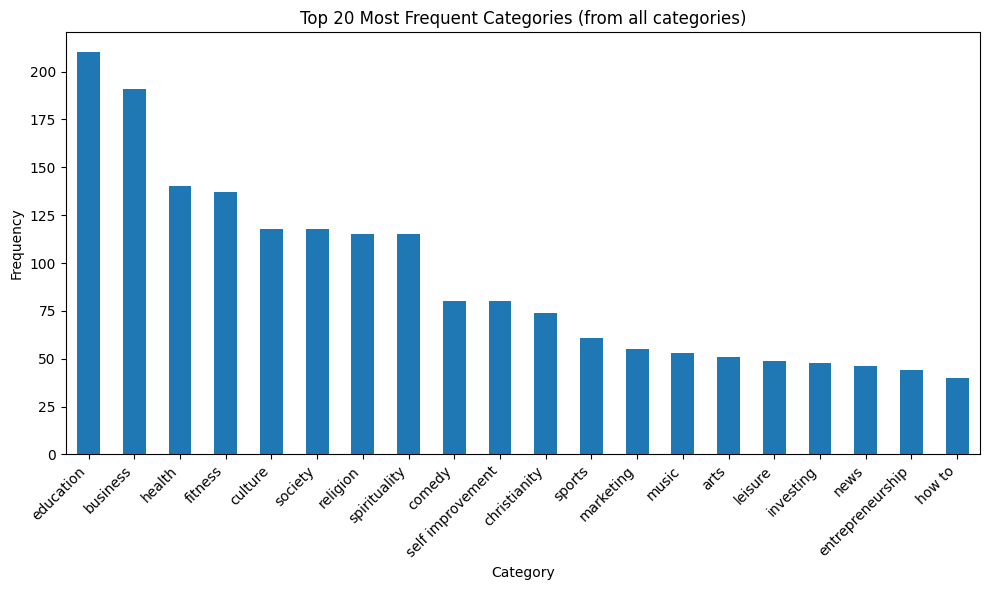

In [31]:
# Combine all category columns into a single Series
all_categories_series = pd.Series(episode_df1[category_columns].values.flatten()).dropna()

# Get the top 20 most frequent categories
top_20_categories = all_categories_series.value_counts().head(20)

# Create a bar chart of the top 20 categories
plt.figure(figsize=(10, 6))
top_20_categories.plot(kind='bar')
plt.title('Top 20 Most Frequent Categories (from all categories)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2.6.4.2 Distribution of Top 20 Most Frequent Categories (from category1)

Here we show the **top 20 most frequent categories in `category1`**. This provides insights into the primary genres and main topics covered by the podcasts in the dataset. Analyzing the distribution of the primary category is crucial for understanding the core thematic composition of the data and for informing decisions about episode-level classification tasks.

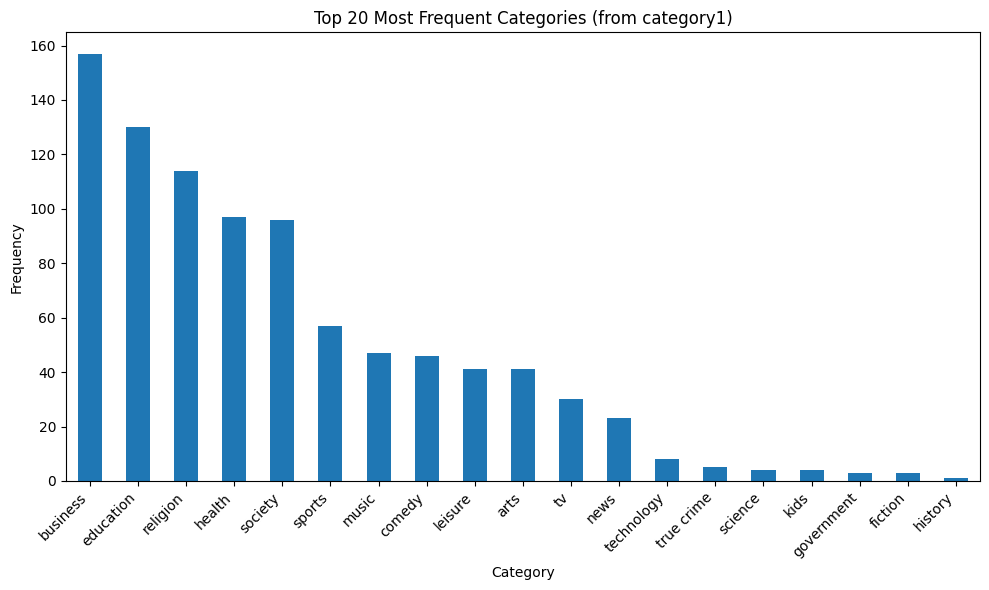

In [32]:
# Combine all category columns into a single Series
all_categories = episode_df1['category1'].values.flatten()
all_categories_series = pd.Series(all_categories).dropna()

# Get the top 20 most frequent categories
top_20_categories = all_categories_series.value_counts().head(20)

# Create a bar chart of the top 20 categories
plt.figure(figsize=(10, 6))
top_20_categories.plot(kind='bar')
plt.title('Top 20 Most Frequent Categories (from category1)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2.6.4.3 Distribution of Top 20 Most Frequent Categories (from category2)

And here we show the top 20 most frequent categories in category2. Examining this distribution helps reveal common secondary themes or sub-genres present in the podcast episodes.

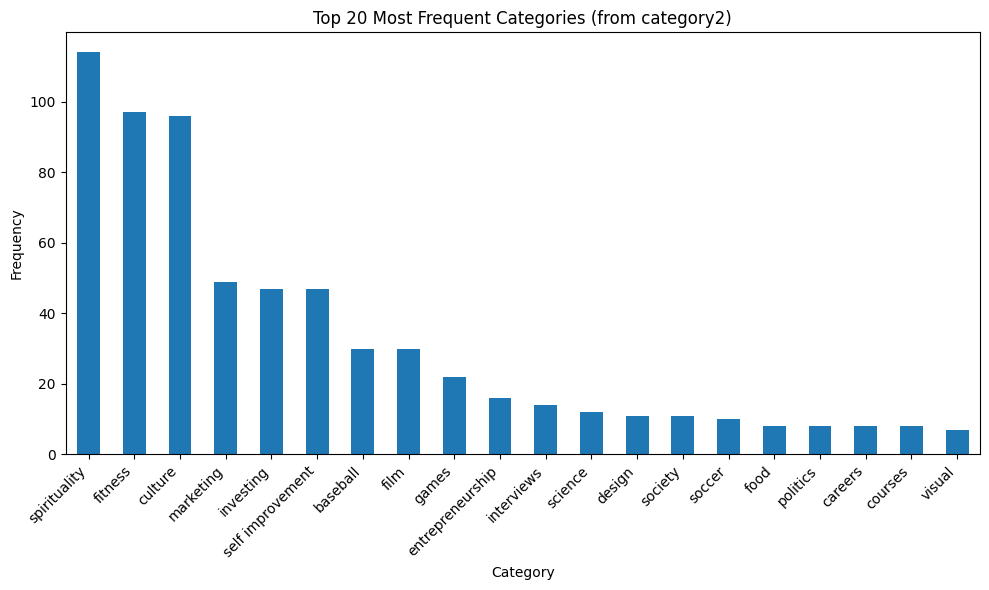

In [33]:
# Combine all category columns into a single Series
all_categories = episode_df1['category2'].values.flatten()
all_categories_series = pd.Series(all_categories).dropna()

# Get the top 20 most frequent categories
top_20_categories = all_categories_series.value_counts().head(20)

# Create a bar chart of the top 20 categories
plt.figure(figsize=(10, 6))
top_20_categories.plot(kind='bar')
plt.title('Top 20 Most Frequent Categories (from category2)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.6.5 Final Results 

In [34]:
for i in range(10, 15):
    ep_title = episode_df1.loc[i, 'epTitle']
    mp3_url = episode_df1.loc[i, 'mp3url']
    turns = episode_df1.loc[i, 'turns_list']
    categories = episode_df1.loc[i, category_columns]
    category_list = [cat for cat in categories if cat is not None]


    print(f"\n{'='*60}")
    print(f"Episode {i+1}: {ep_title}")
    print(f"MP3 URL   : {mp3_url}")
    print(f"Categories: {category_list}")
    print(f"Turns     : {len(turns)}")
    print(f"{'-'*60}")

    for t in turns[:8]:  # show first 8 turns
        preview = t['turnText'][:100].replace('\n', ' ') + ('...' if len(t['turnText']) > 100 else '')
        print(f"[{t['speaker']}] {preview}")
    if len(turns) > 8:
        print(f"... ({len(turns) - 8} more turns)")
    print(f"{'='*60}\n")



Episode 11: Why is it so hard to lose weight the 2nd time?
MP3 URL   : https://traffic.megaphone.fm/APO4719798278.mp3
Categories: ['health', 'fitness']
Turns     : 20
------------------------------------------------------------
[['SPEAKER_01']] lets go make excuses im talking im talking lets go youre timing one minute im talking im talking you...
[['SPEAKER_00']] welcome get fit radio host irene cook radio show helps lead healthy lifestyle well point anybody eve...
[['SPEAKER_00']]  theyve kept first try 95 people unsuccessful keeping weight try try lets talk losing weight second ...
[['SPEAKER_00']] cess first time many times people lose weight might lose 5 pounds 6 pounds dont really consider big ...
[['SPEAKER_00']] ealthy fluctuation subsequent amount weight majority goes huge lifestyle change adapt new program ch...
[['SPEAKER_00']] fficult lose weight every time gain back crazy concrete psychological reason case constant cycle yet...
[['SPEAKER_00']] kes feel full increases anot

## 3. Split Datasets

In this section, we split the dataset into **training** and **validation** sets.

In [35]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(episode_df1, test_size=0.2, random_state=42)

print("Split Overview")
print("-" * 40)
print(f"Total episodes     : {len(episode_df1)}")
print(f"Train episodes     : {len(train)}")
print(f"Validation episodes: {len(val)}\n")


Split Overview
----------------------------------------
Total episodes     : 907
Train episodes     : 725
Validation episodes: 182



## 4. Next Steps (Proof of Concept) 

### 4.1 Emotional Detector  (Early Demonstration)

In [36]:
import torch

device = 'cpu'
if torch.backends.mps.is_available() : device = 'mps'
if torch.cuda.is_available(): device = 'cuda'

print("Using device: ", device)

Using device:  mps


In [37]:
from transformers import pipeline

# Sample a few episodes and flatten their turns
df_sample = episode_df1.dropna(subset=['turns_list']).sample(30, random_state=41)
turns_df = (
    df_sample
    .explode('turns_list', ignore_index=True)
    .dropna(subset=['turns_list'])
)

# Extract episode title and text
turns_df = pd.DataFrame([
    {'epTitle': row.epTitle, 'turnText': row.turns_list.get('turnText', '').strip()}
    for _, row in turns_df.iterrows() if 'turnText' in row.turns_list
])
turns_df = turns_df[turns_df['turnText'] != '']

# Load emotion detection model
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    device=device
)

# Run model in batches
batch_size = 8
texts = turns_df['turnText'].tolist()

def batched_emotions(texts, batch_size=8):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = emotion_classifier(batch, truncation=True)
        results.extend(preds)
    return results

batch_results = batched_emotions(texts, batch_size)

# Extract labels and scores
turns_df['emotion'] = [r[0]['label'] if r else None for r in batch_results]
turns_df['emotion_score'] = [r[0]['score'] if r else None for r in batch_results]

turns_df.head(20)


/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/envs/nlp/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


,epTitle,turnText,emotion,emotion_score
0,Ep2: Planet Puffin - The Puffins’ Return,podcast supported advertising outside uk mus,neutral,0.823450
1,Ep2: Planet Puffin - The Puffins’ Return,ic hey im ryan reynolds mint mobile like oppos...,surprise,0.476022
2,Ep2: Planet Puffin - The Puffins’ Return,hating thats right cutting price mint unlimite...,anger,0.597853
3,Ep2: Planet Puffin - The Puffins’ Return,bbc sounds radio podcasts see morning light he...,neutral,0.597641
4,Ep2: Planet Puffin - The Puffins’ Return,youll love anothers night eye mint,joy,0.508911
5,Ep2: Planet Puffin - The Puffins’ Return,usic beautiful spring day campions sun time gr...,sadness,0.529731
6,Ep2: Planet Puffin - The Puffins’ Return,usic soon,neutral,0.778194
7,Ep2: Planet Puffin - The Puffins’ Return,step path watch every footstep also develop di...,fear,0.978999
8,Ep2: Planet Puffin - The Puffins’ Return,yeah model walked mark way along cliff path ti...,fear,0.616882
9,Ep2: Planet Puffin - The Puffins’ Return,told us could wanted sure werent going tread p...,neutral,0.672224


#### 4.1.1 Aggregate emotions per episode

By aggregating emotion predictions across all speaker turns within each episode, we can understand the overall emotional landscape of a conversation. For each episode, we calculate the proportion of turns associated with different emotions, providing insight into the emotional dynamics throughout the discussion. This aggregation helps reveal patterns like emotional progression, dominant moods, or significant emotional shifts during the episode.

Note: As this small demo only showcases 30 random turnTexts for 30 random episodes, the distribution will only show one emotion for each episode, but this is just to give some insights to what we aim for.

In [38]:
# Group by episode name and emotion to get counts and ratios
emotion_counts = (
    turns_df.groupby(['epTitle', 'emotion'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
    # Optional: sort columns for readability
)

emotion_ratios = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)

emotion_ratios[:20]

emotion,anger,disgust,fear,joy,neutral,sadness,surprise
epTitle,,,,,,,
PHASE 12: GREEN BRACELETS,0.230769,0.000000,0.153846,0.000000,0.000000,0.307692,0.307692
#140: “You Didn’t Come This Far To Only Come This Far' with Neldy Germain,0.092437,0.011204,0.028011,0.229692,0.366947,0.112045,0.159664
#26 - Taco Bell & Etymology,0.041946,0.045302,0.016779,0.083893,0.605705,0.072148,0.134228
067: 2 Lessons About Business From My First Mentor,0.000000,0.000000,0.000000,0.666667,0.333333,0.000000,0.000000
"180: I just want to teach. - Tim Stephenson chats with us about seeing the opportunity in every situation, paying attention to what's around you so you can bring it into your classroom, and finding yo",0.000000,0.000000,0.043165,0.330935,0.366906,0.079137,0.179856
"185 - Adaptation and Collaboration. - Ryann Fapohunda chats with us about adapting things to your classroom and school, collaborating more with other educators, and the power of extending your profes",0.000000,0.009434,0.009434,0.386792,0.452830,0.056604,0.084906
A Budding Affair,0.200573,0.014327,0.017192,0.114613,0.412607,0.126074,0.114613
Anger Management at Close Quarters,0.195122,0.000000,0.121951,0.353659,0.097561,0.134146,0.097561
Ask Marco - Can I Refinance a Property Held in My LLC | PREI 238,0.000000,0.000000,0.000000,0.454545,0.545455,0.000000,0.000000


### 4.1.2 Average Emotion Distribution

The emotion distribution below shows that 'neutral' is indeed the most frequent classification, which aligns with the nature of podcast conversations - many turns consist of short, functional utterances even after filtering, that carry little emotional content. While the model can detect a range of emotions (anger, disgust, fear, joy, neutral, sadness, surprise), neutral dominates the distribution due to these brief conversational elements. This suggests that for meaningful emotional analysis, we might want to focus on longer turns or aggregate emotions across conversation segments rather than individual short turns.

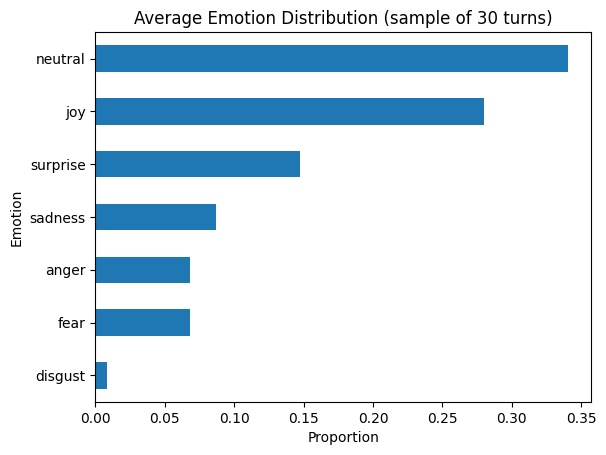

In [39]:
emotion_ratios.mean().sort_values().plot(kind='barh')
plt.title("Average Emotion Distribution (sample of 30 turns)")
plt.xlabel("Proportion")
plt.ylabel("Emotion")
plt.show()

#### 4.1.3 Emotional Graph 

From this aggregated data, we will generate an emotion distribution graph, where each bar (or segment) represents the proportion of emotions—such as joy, sadness, anger, or surprise—present in an episode.

This visualization will help us:

* Identify episodes with strong emotional polarization or balance.
* Explore correlations between emotional tone and episode categories or listener engagement.
* Provide richer contextual features for downstream tasks such as recommendation systems or content-based classification.

### 4.2 Category Classification

This section contains only the initial data-preparation steps for a future episode-level category classification task. It does NOT include model training or evaluation. The purpose here is to produce a clean, ready dataset for later modeling.

Contents:
- Sample selection & label extraction: filter episodes with non-null `combined_turnText` and `category1`; optionally restrict to the top‑N frequent categories to keep the sample manageable; extract and encode the primary category as the target vector.
- Text vectorization (TF‑IDF): fit a `TfidfVectorizer` (unigrams + bigrams, basic stopword filtering, and an optional max feature/min document frequency) and transform the selected episode texts into sparse TF‑IDF features.

Result: a prepared feature matrix (`X_tfidf`) and label vector (`y`) stored for the next assignment where we will implement model training, evaluation, and error analysis.

#### 4.2.1 Sample Selection and Label Extraction

Here we'll:
1. Load episode data and select relevant columns
2. Keep only episodes with non-null text and category
3. Focus on top-K most frequent categories
4. Create feature matrix X and target vector y

In [40]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Select rows with non-null text and category
df = episode_df1[['epTitle', 'turns_list', 'category1']].dropna()

# Keep only top 20 most frequent categories
top_k = 20
top_categories = df['category1'].value_counts().nlargest(top_k).index
df = df[df['category1'].isin(top_categories)]

# Concatenate all filtered_texts in turns_list for each episode
def concat_filtered_text(turns):
    return ' '.join([turn.get('turnText', '') for turn in turns if isinstance(turn, dict)])

df['all_text'] = df['turns_list'].apply(concat_filtered_text)

# Create feature matrix X and target vector y
X = df['all_text']
y = df['category1']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

print("Dataset shape:", df.shape) 
print("\nCategory distribution:")
for i, category in enumerate(le.classes_):
    count = (y == i).sum()
    print(f"{category}: {count} episodes ({count/len(y):.1%})")

Dataset shape: (907, 4)

Category distribution:
arts: 41 episodes (4.5%)
business: 157 episodes (17.3%)
comedy: 46 episodes (5.1%)
education: 130 episodes (14.3%)
fiction: 3 episodes (0.3%)
government: 3 episodes (0.3%)
health: 97 episodes (10.7%)
history: 1 episodes (0.1%)
kids: 4 episodes (0.4%)
leisure: 41 episodes (4.5%)
music: 47 episodes (5.2%)
news: 23 episodes (2.5%)
religion: 114 episodes (12.6%)
science: 4 episodes (0.4%)
society: 96 episodes (10.6%)
sports: 57 episodes (6.3%)
technology: 8 episodes (0.9%)
true crime: 5 episodes (0.6%)
tv: 30 episodes (3.3%)


#### 4.2.2 Text Vectorization (TF-IDF)

Convert the text data into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). This:
- Captures word importance through term frequency and document frequency
- Handles common words appropriately through IDF weighting
- Creates a sparse feature matrix suitable for classification

In [41]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,  # Limit vocabulary size
    min_df=5,           # Ignore terms that appear in < 5 documents
    ngram_range=(1, 2), # Use unigrams and bigrams
    stop_words='english'
)

# Fit and transform the text data
X_tfidf = tfidf.fit_transform(X)

print("TF-IDF feature matrix shape:", X_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))
print("\nSample features:", list(tfidf.get_feature_names_out())[:10])

TF-IDF feature matrix shape: (907, 10000)
Number of features: 10000

Sample features: ['10', '10 15', '10 days', '10 million', '10 minute', '10 minutes', '10 people', '10 year', '10 years', '100']


#### 4.2.3 Planned model training, evaluation and next steps (summary)



In a later assignment we will build on the prepared features (`X_tfidf`) and labels (`y`) to train and evaluate classification models. High-level plan:

- Train/validation split: stratified 80/20 (optionally hold out a small test set); consider cross-validation for robust estimates.
- Baseline model: Logistic Regression (class_weight='balanced', solver='saga' or 'liblinear') with optional hyperparameter tuning via grid search or randomized CV.
- Metrics: report accuracy, precision/recall/F1 (micro/macro), and per-class support; plot a confusion matrix and calibration curves where relevant.
- Interpretability & error analysis: inspect top features (model coefficients) per class, review misclassified episode excerpts to diagnose label noise or ambiguous content.
- Probabilities & thresholding: show top‑k predicted categories and confidences; consider thresholding for precision-oriented applications.
- Persistence: save vectorizer/tokenizer, label encoder, and trained model (joblib) for later inference.

Future upgrades: experiment with pretrained embeddings or fine-tuned transformers, multi-label setups, and class-rebalancing strategies.

### 4.3 Potential Brand Safety Analysis



This section might explore brand safety analysis of podcast content, though the specific approach and implementation details are still under consideration. Here's a preliminary outline of what could potentially be included:

1. **Content Safety Assessment** (tentative approach)
   - We might analyze text for potentially sensitive or controversial content
   - This could involve identifying mentions of specific topics or themes
   - The scope would need careful definition based on available resources and project requirements

2. **Possible Analysis Methods**
   - We could consider keyword-based detection of sensitive topics
   - Alternatively, we might explore pre-trained content classification models
   - The choice of method would depend on feasibility and accuracy requirements

3. **Potential Challenges**
   - Context interpretation in conversational content
   - Handling nuanced discussions of sensitive topics
   - Balancing detection accuracy with false positives
   - Need for careful consideration of bias in analysis methods

4. **Possible Output Format**
   - If implemented, we might provide episode-level safety ratings
   - Could potentially include segment-level annotations
   - Format and granularity would need to align with practical use cases

Note: This section represents potential future work and the actual implementation may vary significantly based on feasibility analysis and project constraints. The approach to brand safety analysis would need careful consideration of ethical implications and bias mitigation.

### 4.4 Audience Alignment Prediction

This short exploratory section considers ways to estimate which audience segments are likely to engage with an episode using its content signals (topics, tone, and emotion). Based on emotional and topical embeddings, we could apply a zero-shot classification approach to infer likely audience segments (e.g., “young professionals”, “tech enthusiasts”, “general entertainment”). This is an exploratory feasibility step intended to demonstrate the potential of emotion-aware audience profiling rather than a committed methodology; the final approach will depend on available listener data and time constraints.